# Kibble-Zurek Mechanism — 3D Ising Model (GPU)

The Kibble-Zurek mechanism (KZM) predicts that cooling through a phase transition at finite rate τ_Q produces topological defects with density:

  ρ - ρ_eq ~ τ_Q^(-κ)

For domain wall density (fraction of misaligned bonds) in 3D Ising with ν=0.6301 and z=2 (Metropolis, Model A):

  κ_theory = ν/(1 + νz) = 0.6301 / (1 + 0.6301×2) = 0.279

**Protocol**: Linear ramp T=6.0 → Tc=4.5115 over τ_Q sweeps, then snap-freeze to T≈0 (5 sweeps) to preserve frozen-in defects without coarsening.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import os

data_dir = 'data'
datasets = {}
for fname in sorted(os.listdir(data_dir)):
    if fname.startswith('kz_N') and fname.endswith('.csv'):
        key = fname.replace('.csv', '')
        df = pd.read_csv(os.path.join(data_dir, fname))
        # Skip datasets where rho goes to zero (system too small)
        if (df['rho'] > 0.01).sum() >= 8:
            datasets[key] = df
            print(f"Loaded {key}: {len(df)} rows, rho range [{df['rho'].min():.4f}, {df['rho'].max():.4f}]")
        else:
            print(f"Skipped {key}: too many zero-rho points (system too small)")

# KZM theory for domain wall density
nu = 0.6301
z = 2.0
kzm_exponent = nu / (1 + nu * z)
print(f"\nKZM theory exponent κ = {kzm_exponent:.4f}")

Skipped kz_N20: too many zero-rho points (system too small)
Skipped kz_N30: too many zero-rho points (system too small)
Loaded kz_N50: 15 rows, rho range [0.0547, 0.0729]
Loaded kz_N80: 15 rows, rho range [0.0585, 0.0727]

KZM theory exponent κ = 0.2788


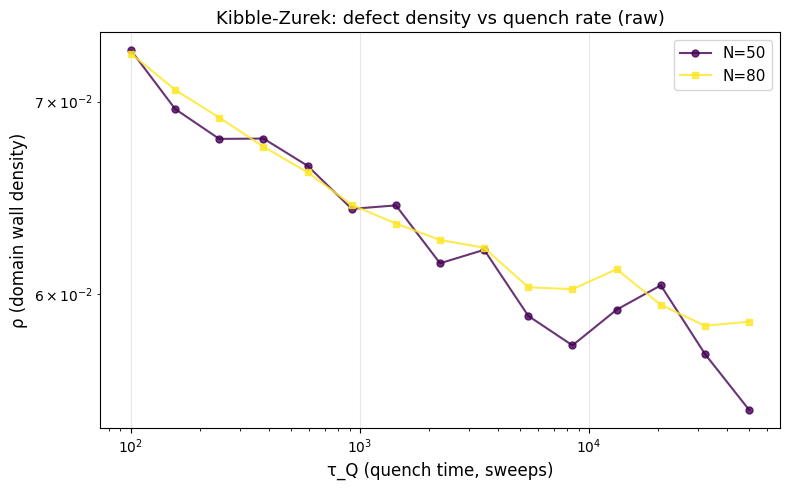

In [2]:
# Raw data plot
fig, ax = plt.subplots(figsize=(8, 5))

cmap = plt.cm.viridis
colors = {k: cmap(i / max(len(datasets)-1, 1)) for i, k in enumerate(datasets)}
markers = ['o', 's', 'D', '^', 'v']

for i, (key, df) in enumerate(datasets.items()):
    n = key.split('N')[1]
    ax.loglog(df['tau_q'], df['rho'], markers[i % len(markers)] + '-',
              color=colors[key], label=f'N={n}', alpha=0.8, markersize=5)

ax.set_xlabel('τ_Q (quench time, sweeps)', fontsize=12)
ax.set_ylabel('ρ (domain wall density)', fontsize=12)
ax.set_title('Kibble-Zurek: defect density vs quench rate (raw)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(data_dir, 'kz_raw.png'), dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Nonlinear fit: rho = A * tau_q^(-kappa) + rho_eq
def kz_model(tau_q, A, kappa, rho_eq):
    return A * tau_q**(-kappa) + rho_eq

results = []
fits = {}

for key, df in datasets.items():
    n = key.split('N')[1]
    tau = df['tau_q'].values.astype(float)
    rho = df['rho'].values

    # Initial guesses
    rho_eq_guess = rho[-3:].mean()  # average of last 3 points
    A_guess = (rho[0] - rho_eq_guess) * tau[0]**0.3
    
    try:
        popt, pcov = curve_fit(kz_model, tau, rho,
                               p0=[A_guess, 0.3, rho_eq_guess],
                               bounds=([0, 0.01, 0], [np.inf, 3.0, 0.2]),
                               maxfev=10000)
        perr = np.sqrt(np.diag(pcov))
        A_fit, kappa_fit, rho_eq_fit = popt
        A_err, kappa_err, rho_eq_err = perr
        
        # R² for the fit
        rho_pred = kz_model(tau, *popt)
        ss_res = np.sum((rho - rho_pred)**2)
        ss_tot = np.sum((rho - rho.mean())**2)
        r2 = 1 - ss_res / ss_tot
        
        pct_err = abs(kappa_fit - kzm_exponent) / kzm_exponent * 100
        
        fits[key] = popt
        results.append({
            'N': n, 'κ_measured': kappa_fit, 'κ_err': kappa_err,
            'κ_theory': kzm_exponent, 'pct_error': pct_err,
            'ρ_eq': rho_eq_fit, 'A': A_fit, 'R²': r2
        })
        
        print(f"N={n}: κ = {kappa_fit:.4f} ± {kappa_err:.4f}  "
              f"(theory: {kzm_exponent:.4f}, error: {pct_err:.1f}%)  "
              f"ρ_eq = {rho_eq_fit:.5f}  R² = {r2:.4f}")
    except Exception as e:
        print(f"N={n}: fit failed — {e}")

if results:
    df_results = pd.DataFrame(results)
    print("\nSummary:")
    print(df_results.to_string(index=False))

N=50: κ = 0.1563 ± 0.0838  (theory: 0.2788, error: 43.9%)  ρ_eq = 0.04656  R² = 0.9451
N=80: κ = 0.2930 ± 0.0381  (theory: 0.2788, error: 5.1%)  ρ_eq = 0.05589  R² = 0.9895

Summary:
 N  κ_measured    κ_err  κ_theory  pct_error     ρ_eq        A       R²
50    0.156268 0.083791  0.278781  43.945956 0.046563 0.052525 0.945129
80    0.293001 0.038095  0.278781   5.101064 0.055895 0.065213 0.989500


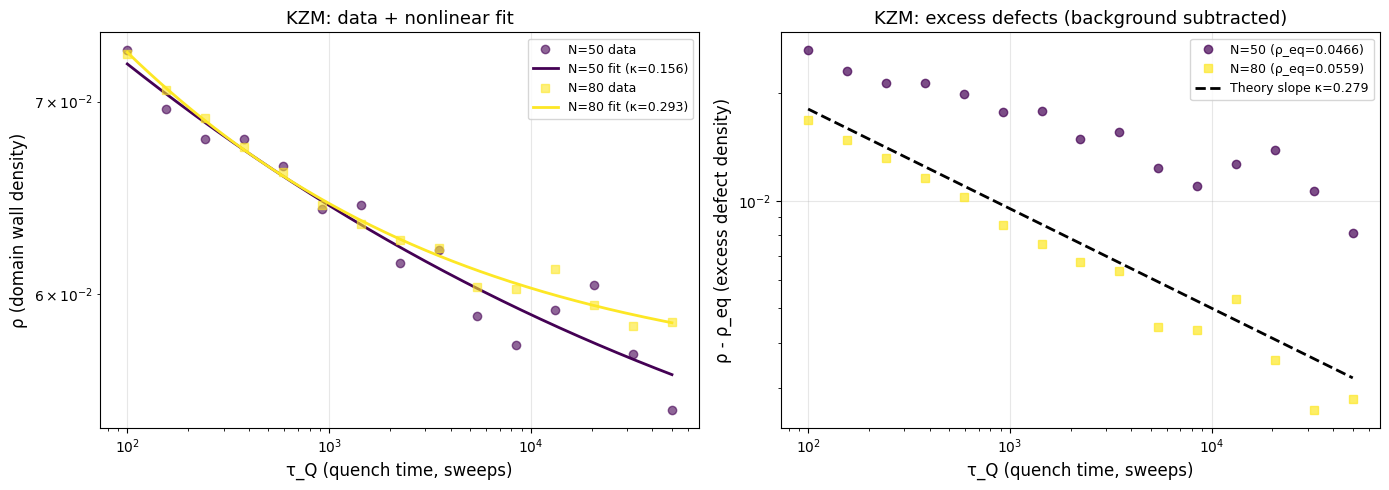

In [4]:
# Fit plot with theory comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw data + fit curves
ax = axes[0]
for i, (key, df) in enumerate(datasets.items()):
    n = key.split('N')[1]
    tau = df['tau_q'].values.astype(float)
    rho = df['rho'].values
    ax.loglog(tau, rho, markers[i % len(markers)],
              color=colors[key], label=f'N={n} data', alpha=0.6, markersize=6)
    if key in fits:
        tau_smooth = np.logspace(np.log10(tau.min()), np.log10(tau.max()), 200)
        rho_fit = kz_model(tau_smooth, *fits[key])
        ax.loglog(tau_smooth, rho_fit, '-', color=colors[key], linewidth=2,
                  label=f'N={n} fit (κ={fits[key][1]:.3f})')

ax.set_xlabel('τ_Q (quench time, sweeps)', fontsize=12)
ax.set_ylabel('ρ (domain wall density)', fontsize=12)
ax.set_title('KZM: data + nonlinear fit', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: excess defect density (rho - rho_eq) vs tau_q
ax = axes[1]
for i, (key, df) in enumerate(datasets.items()):
    n = key.split('N')[1]
    if key not in fits:
        continue
    tau = df['tau_q'].values.astype(float)
    rho = df['rho'].values
    rho_eq = fits[key][2]
    excess = rho - rho_eq
    mask = excess > 0
    if mask.sum() < 3:
        continue
    ax.loglog(tau[mask], excess[mask], markers[i % len(markers)],
              color=colors[key], label=f'N={n} (ρ_eq={rho_eq:.4f})', alpha=0.7, markersize=6)

# Theory slope
if fits:
    ref_key = list(fits.keys())[-1]  # use largest N
    ref_df = datasets[ref_key]
    tau_ref = ref_df['tau_q'].values.astype(float)
    A_ref = fits[ref_key][0]
    tau_line = np.logspace(np.log10(tau_ref.min()), np.log10(tau_ref.max()), 100)
    excess_theory = A_ref * tau_line**(-kzm_exponent)
    ax.loglog(tau_line, excess_theory, 'k--', linewidth=2,
              label=f'Theory slope κ={kzm_exponent:.3f}')

ax.set_xlabel('τ_Q (quench time, sweeps)', fontsize=12)
ax.set_ylabel('ρ - ρ_eq (excess defect density)', fontsize=12)
ax.set_title('KZM: excess defects (background subtracted)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(data_dir, 'kz_fit.png'), dpi=150, bbox_inches='tight')
plt.show()

## Notes

- **Protocol**: Ramp T=6.0 → Tc=4.5115 over τ_Q sweeps, then snap-freeze (5 sweeps at T≈0.01) to preserve frozen defects
- κ_theory = ν/(1+νz) = 0.279 for domain wall density with Metropolis dynamics (z=2)
- The equilibrium background ρ_eq at Tc is subtracted via nonlinear fit: ρ = A·τ_Q^(-κ) + ρ_eq
- Small lattices (N≤30) fully order even at moderate quench rates — need N≥50
- GPU checkerboard Metropolis used for N=50, 80